
# Twin Prime 15-Rail Spillover + Endpoint Discrepancy Engine

This notebook codes the current Nexus twin-prime hinge:

$$
D(n)=\min\{p>2:p\mid n(n+2)\}
$$

$$
\sigma(n)=\frac{D(n)}{\sqrt{n+2}}
$$

Twin primes are exactly the strict spillovers:

$$
\boxed{\sigma(n)>1}
$$

Boundary hits are fake witnesses:

$$
\sigma(n)=1
$$

The engine works on the 15 twin-admissible rails modulo:

$$
W=210=2\cdot3\cdot5\cdot7
$$

where:

$$
\gcd(r,210)=1,\qquad \gcd(r+2,210)=1.
$$

The proof-hinge being measured is the rail-local endpoint discrepancy:

$$
E_{2,r}(X)=T_{2,r}(X)-\frac{1}{15}M_2(X)
$$

with normalized diagnostic:

$$
Z_r(X)=\frac{E_{2,r}(X)}{\sqrt{M_2(X)/15}}.
$$

This notebook does **not** assert an unconditional proof. It instruments the exact obstruction: whether endpoint co-survival discrepancy can permanently cancel the growing main term.

Δ Nexus read:

$$
\text{Twin primes}=
\text{zero-interior-burden endpoint survivors crossing the square-root horizon.}
$$


Twin-prime 15-rail spillover/discrepancy engine
Rails: [11, 17, 29, 41, 59, 71, 101, 107, 137, 149, 167, 179, 191, 197, 209]
Running X=100,000 ...
Running X=1,000,000 ...
Running X=5,000,000 ...
Running X=20,000,000 ...

Summary:
          X  candidates  twins_sigma_gt_1  tail_gt_099  tail_gt_035  \
0    100000        7143              1222         1253         2342   
1   1000000       71427              8167         8247        14339   
2   5000000      357143             32461        32689        53817   
3  20000000     1428572            107405       108032       171554   

   near_miss_099_to_1  boundary_contacts  min_rail  max_rail  max_min_ratio  \
0                  31                 23        73        95       1.301370   
1                  80                 48       518       572       1.104247   
2                 228                 87      2114      2220       1.050142   
3                 627                141      7062      7261       1.028179   

       chi2  chi2_

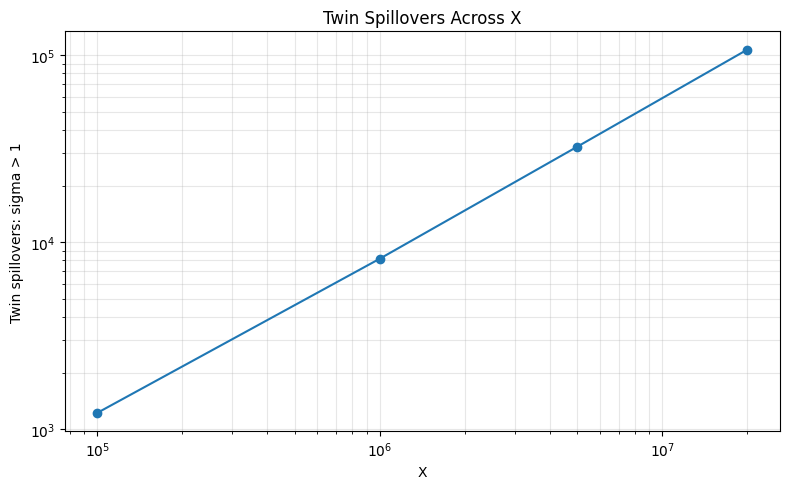

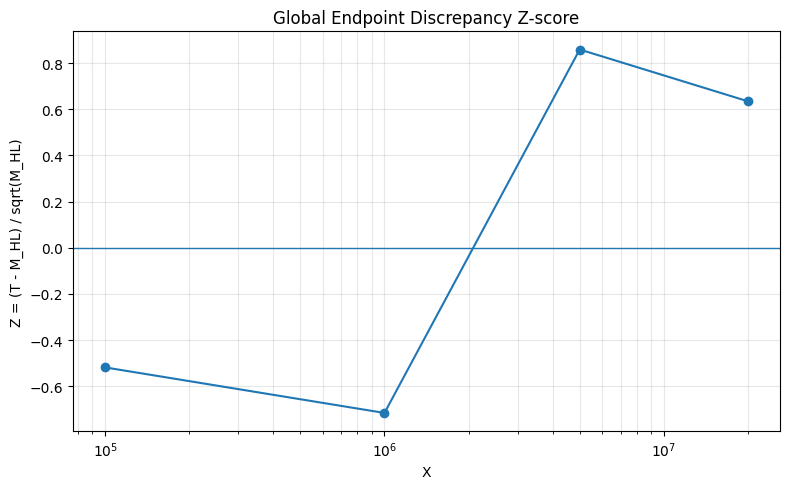

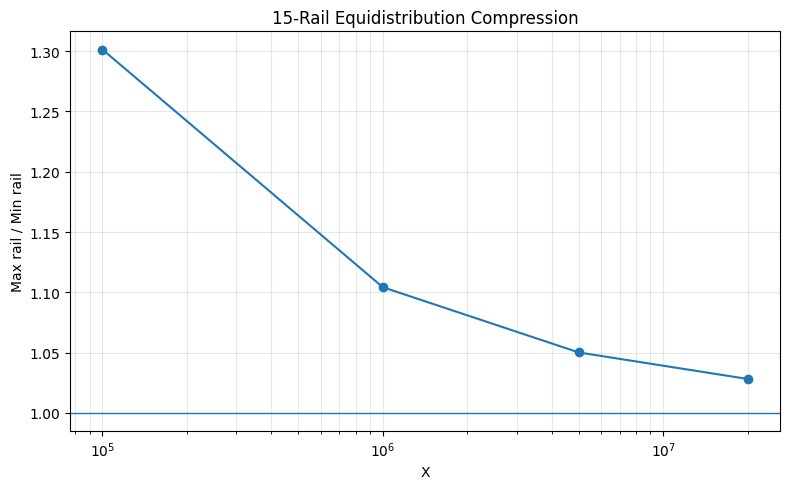

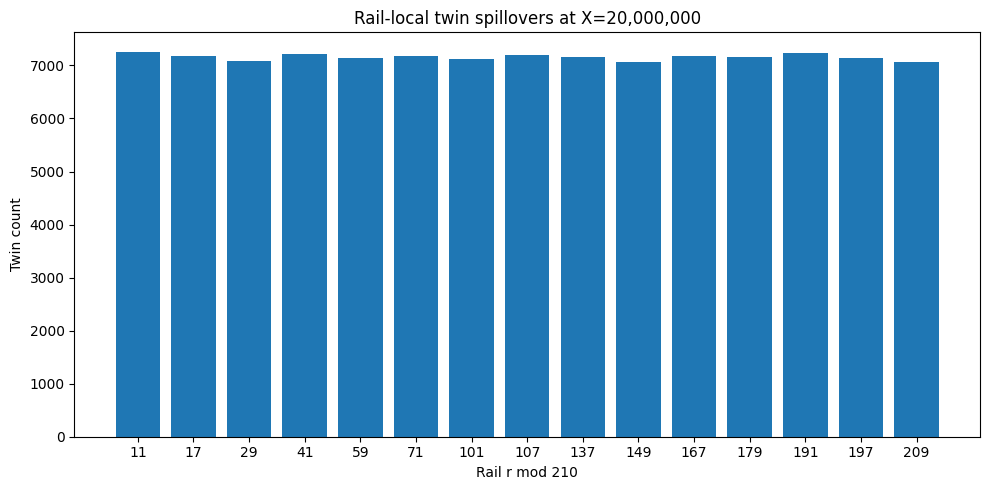

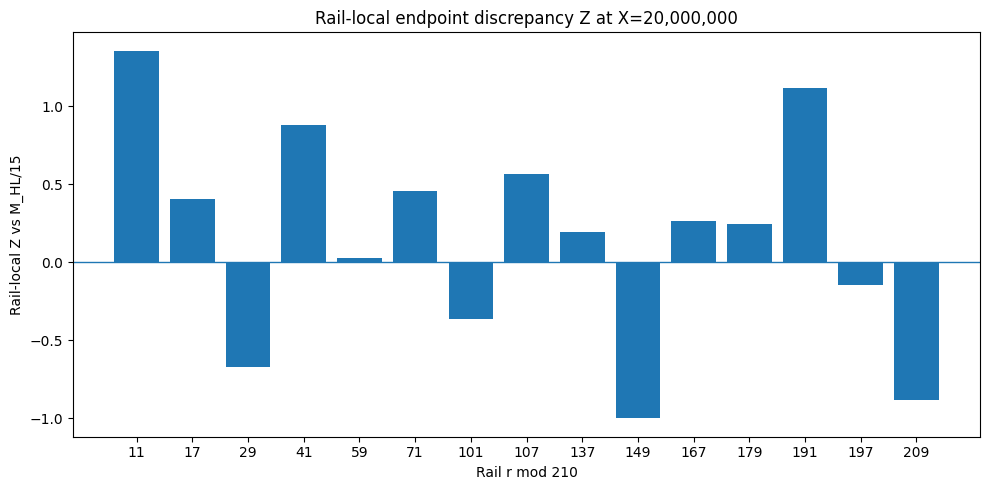

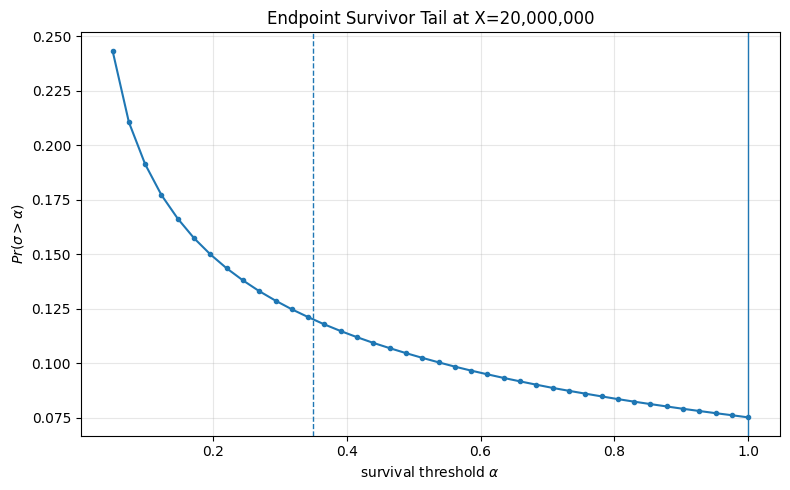


Outputs saved to: twin_prime_spillover_outputs


In [1]:

# Twin Prime 15-Rail Spillover + Endpoint Discrepancy Engine
# Dean Kulik / QuHarmonics — Nexus Primorial Clearance Algebra
#
# Purpose:
#   Measure the exact executable hinge for the twin-prime branch:
#       D(n) = min odd prime p dividing n(n+2)
#       sigma(n) = D(n) / sqrt(n+2)
#       twin prime iff sigma(n) > 1
#
#   Work on the 15 twin-admissible rails modulo W = 210.
#
# Dependencies:
#   numpy, pandas, matplotlib
#   scipy optional for chi-square p-values

import math
import time
import json
from pathlib import Path
from typing import Dict, List, Tuple, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import scipy.stats as scipy_stats
except Exception:
    scipy_stats = None


# -----------------------------
# CONFIG
# -----------------------------

CONFIG = {
    "W": 210,
    "X_GRID": [100_000, 1_000_000, 5_000_000, 20_000_000],
    # For deeper local runs:
    # "X_GRID": [1_000_000, 5_000_000, 10_000_000, 20_000_000, 50_000_000, 100_000_000],
    "TAIL_THRESHOLDS": [0.35, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00],
    "TAIL_CURVE_POINTS": np.round(np.linspace(0.05, 1.00, 40), 4).tolist(),
    "OUTPUT_DIR": "twin_prime_spillover_outputs",
    "TWIN_PRIME_C2": 0.6601618158468696,
    "LI2_SERIES_TERMS": 6,
}


# -----------------------------
# BASIC SIEVES
# -----------------------------

def prime_sieve_bool(n: int) -> np.ndarray:
    """
    Return boolean array is_prime[0..n].
    """
    if n < 2:
        return np.zeros(n + 1, dtype=bool)

    sieve = np.ones(n + 1, dtype=bool)
    sieve[:2] = False
    sieve[4::2] = False

    root = int(math.isqrt(n))
    for p in range(3, root + 1, 2):
        if sieve[p]:
            sieve[p*p::2*p] = False

    return sieve


def spf_sieve(n: int) -> np.ndarray:
    """
    Smallest prime factor array spf[0..n].
    For primes p, spf[p] = p.
    """
    spf = np.zeros(n + 1, dtype=np.int32)

    if n >= 1:
        spf[1] = 1
    if n >= 2:
        spf[2::2] = 2

    root = int(math.isqrt(n))
    for p in range(3, root + 1, 2):
        if spf[p] == 0:
            spf[p] = p
            start = p * p
            step = 2 * p
            view = spf[start:n+1:step]
            mask = (view == 0)
            view[mask] = p
            spf[start:n+1:step] = view

    zeros = (spf == 0)
    idx = np.nonzero(zeros)[0]
    spf[idx] = idx.astype(np.int32)
    spf[0] = 0
    return spf


# -----------------------------
# PRIMORIAL RAIL STRUCTURE
# -----------------------------

def twin_rails(W: int = 210) -> List[int]:
    """
    15 twin-admissible rails modulo 210:
        gcd(r, W) = 1 and gcd(r+2, W) = 1.
    """
    return [
        r for r in range(1, W)
        if math.gcd(r, W) == 1 and math.gcd((r + 2) % W, W) == 1
    ]


def candidate_ns_for_rail(r: int, X: int, W: int = 210) -> np.ndarray:
    """
    All n <= X on rail r modulo W, excluding n <= 7.
    """
    if r <= 7:
        start = r + W * ((8 - r + W - 1) // W)
    else:
        start = r
    if start > X:
        return np.array([], dtype=np.int64)
    return np.arange(start, X + 1, W, dtype=np.int64)


def subtype_count_formula_delta2(z_primes: Iterable[int]) -> int:
    """
    For a finite primorial wheel W_z, twin-admissible rail count:
        N_W(2) = product_{3 <= p <= z} (p - 2).
    """
    out = 1
    for p in z_primes:
        if p >= 3:
            out *= (p - 2)
    return out


# -----------------------------
# MAIN TERMS / DISCREPANCY
# -----------------------------

def li2_asymptotic_series(X: int, terms: int = 6) -> float:
    """
    Asymptotic expansion:
        Li_2(X) = integral_2^X dt / log(t)^2
        ~ X/log(X)^2 * sum_{k>=0} (k+1)! / log(X)^k.
    """
    L = math.log(X)
    series = sum(math.factorial(k + 1) / (L ** k) for k in range(terms))
    return X / (L * L) * series


def twin_main_hl_series(X: int, C2: float = 0.6601618158468696, terms: int = 6) -> float:
    """
    Hardy-Littlewood smooth estimate:
        M_HL(X) ~ 2 C2 Li_2(X).
    """
    return 2.0 * C2 * li2_asymptotic_series(X, terms=terms)


def twin_main_sqrt_product(X: int) -> float:
    """
    Finite square-root-depth endpoint-survival product:
        M_sqrt(X) = X * product_{3 <= p <= sqrt(X+2)} (1 - 2/p).
    """
    y = int(math.isqrt(X + 2))
    primes_bool = prime_sieve_bool(y)
    primes = np.nonzero(primes_bool)[0]
    prod = 1.0
    for p in primes:
        if p >= 3:
            prod *= (1.0 - 2.0 / p)
    return X * prod


# -----------------------------
# CORE ANALYSIS
# -----------------------------

def analyze_X(
    X: int,
    W: int = 210,
    tail_thresholds: Iterable[float] = (0.35, 0.5, 0.75, 0.90, 0.95, 0.99, 1.0),
    C2: float = 0.6601618158468696,
    li2_terms: int = 6,
    keep_rail_arrays: bool = False,
) -> Dict:
    """
    Analyze the 15 twin rails up to X.

    Exact twin test:
        is_prime[n] and is_prime[n+2]

    Survival-height test:
        D(n) = min(spf[n], spf[n+2])
        sigma(n) = D(n) / sqrt(n+2)
        twin iff sigma(n) > 1

    Boundary contacts:
        sigma(n) == 1 exactly, normally n+2 = q^2 and n prime.
        These are fake spillovers and must NOT be counted as twins.
    """
    t0 = time.time()
    N = X + 2

    is_prime = prime_sieve_bool(N)
    spf = spf_sieve(N)

    rails = twin_rails(W)
    rail_counts: Dict[int, int] = {}
    rail_candidates: Dict[int, int] = {}
    rail_tails: Dict[int, Dict[float, int]] = {}
    rail_boundary_contacts: Dict[int, int] = {}
    rail_near_miss_099_to_1: Dict[int, int] = {}
    rail_Z_HL: Dict[int, float] = {}

    total_candidates = 0
    total_tails = {float(t): 0 for t in tail_thresholds}
    boundary_contacts_total = 0

    retained = {} if keep_rail_arrays else None

    for r in rails:
        ns = candidate_ns_for_rail(r, X, W)
        total_candidates += len(ns)
        rail_candidates[r] = int(len(ns))

        if len(ns) == 0:
            rail_counts[r] = 0
            rail_tails[r] = {float(t): 0 for t in tail_thresholds}
            rail_boundary_contacts[r] = 0
            rail_near_miss_099_to_1[r] = 0
            continue

        twin_mask = is_prime[ns] & is_prime[ns + 2]
        count = int(np.sum(twin_mask))
        rail_counts[r] = count

        D = np.minimum(spf[ns], spf[ns + 2]).astype(np.int64)
        sigma = D.astype(np.float64) / np.sqrt(ns + 2)

        this_tails = {}
        for t in tail_thresholds:
            c = int(np.sum(sigma > float(t)))
            this_tails[float(t)] = c
            total_tails[float(t)] += c

        rail_tails[r] = this_tails

        # Exact fake-witness boundary: sigma == 1 via D^2 == n+2 but not true twin.
        bc_mask = (D * D == (ns + 2)) & (~twin_mask)
        bc = int(np.sum(bc_mask))
        rail_boundary_contacts[r] = bc
        boundary_contacts_total += bc

        rail_near_miss_099_to_1[r] = int(np.sum((sigma > 0.99) & (sigma <= 1.0)))

        if keep_rail_arrays:
            retained[r] = {
                "n": ns,
                "D": D,
                "sigma": sigma,
                "is_twin": twin_mask,
                "boundary_contact": bc_mask,
            }

    T = int(sum(rail_counts.values()))
    values = np.array([rail_counts[r] for r in rails], dtype=float)

    expected = np.full(len(rails), T / len(rails), dtype=float)
    chi2 = float(np.sum((values - expected) ** 2 / expected)) if T > 0 else float("nan")
    p_value = float(scipy_stats.chi2.sf(chi2, len(rails) - 1)) if scipy_stats is not None and T > 0 else None

    M_HL = twin_main_hl_series(X, C2=C2, terms=li2_terms)
    M_sqrt = twin_main_sqrt_product(X)

    E_HL = T - M_HL
    Z_HL = E_HL / math.sqrt(M_HL) if M_HL > 0 else float("nan")

    per_rail_expected = M_HL / len(rails)
    per_rail_sigma = math.sqrt(per_rail_expected) if per_rail_expected > 0 else float("nan")
    for r in rails:
        rail_Z_HL[r] = (rail_counts[r] - per_rail_expected) / per_rail_sigma

    elapsed = time.time() - t0

    result = {
        "X": int(X),
        "W": int(W),
        "rails": rails,
        "num_rails": len(rails),
        "total_candidates": int(total_candidates),
        "T_twins_sigma_gt_1": T,
        "tail_counts": total_tails,
        "boundary_contacts_sigma_eq_1_not_twin": int(boundary_contacts_total),
        "near_miss_099_to_1": int(total_tails.get(0.99, 0) - total_tails.get(1.0, 0)),
        "rail_counts": rail_counts,
        "rail_candidates": rail_candidates,
        "rail_tails": rail_tails,
        "rail_boundary_contacts": rail_boundary_contacts,
        "rail_near_miss_099_to_1": rail_near_miss_099_to_1,
        "min_rail_count": int(values.min()) if len(values) else None,
        "max_rail_count": int(values.max()) if len(values) else None,
        "max_min_ratio": float(values.max() / values.min()) if len(values) and values.min() > 0 else None,
        "chi2": chi2,
        "chi2_p_value": p_value,
        "M_HL_series": float(M_HL),
        "M_sqrt_product": float(M_sqrt),
        "E_HL_series": float(E_HL),
        "Z_HL_series": float(Z_HL),
        "rail_Z_HL": rail_Z_HL,
        "elapsed_seconds": elapsed,
    }

    if keep_rail_arrays:
        result["_retained_arrays"] = retained

    return result


def run_grid(config: Dict = CONFIG):
    """
    Run configured X grid and return:
        summary_df, raw_results_by_X
    """
    raw = {}
    rows = []

    for X in config["X_GRID"]:
        print(f"Running X={X:,} ...")
        res = analyze_X(
            X=X,
            W=config["W"],
            tail_thresholds=config["TAIL_THRESHOLDS"],
            C2=config["TWIN_PRIME_C2"],
            li2_terms=config["LI2_SERIES_TERMS"],
        )
        raw[X] = res

        row = {
            "X": X,
            "candidates": res["total_candidates"],
            "twins_sigma_gt_1": res["T_twins_sigma_gt_1"],
            "tail_gt_099": res["tail_counts"].get(0.99, None),
            "tail_gt_035": res["tail_counts"].get(0.35, None),
            "near_miss_099_to_1": res["near_miss_099_to_1"],
            "boundary_contacts": res["boundary_contacts_sigma_eq_1_not_twin"],
            "min_rail": res["min_rail_count"],
            "max_rail": res["max_rail_count"],
            "max_min_ratio": res["max_min_ratio"],
            "chi2": res["chi2"],
            "chi2_p_value": res["chi2_p_value"],
            "M_HL_series": res["M_HL_series"],
            "E_HL_series": res["E_HL_series"],
            "Z_HL_series": res["Z_HL_series"],
            "M_sqrt_product": res["M_sqrt_product"],
            "elapsed_seconds": res["elapsed_seconds"],
        }
        rows.append(row)

    return pd.DataFrame(rows), raw


# -----------------------------
# PLOTS
# -----------------------------

def plot_summary(summary_df: pd.DataFrame, output_dir: str = "twin_prime_spillover_outputs") -> None:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    plt.figure(figsize=(8, 5))
    plt.plot(summary_df["X"], summary_df["twins_sigma_gt_1"], marker="o")
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("X")
    plt.ylabel("Twin spillovers: sigma > 1")
    plt.title("Twin Spillovers Across X")
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.savefig(out / "twin_spillovers_vs_X.png", dpi=160)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(summary_df["X"], summary_df["Z_HL_series"], marker="o")
    plt.axhline(0, linewidth=1)
    plt.xscale("log")
    plt.xlabel("X")
    plt.ylabel("Z = (T - M_HL) / sqrt(M_HL)")
    plt.title("Global Endpoint Discrepancy Z-score")
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.savefig(out / "global_discrepancy_Z_vs_X.png", dpi=160)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(summary_df["X"], summary_df["max_min_ratio"], marker="o")
    plt.axhline(1.0, linewidth=1)
    plt.xscale("log")
    plt.xlabel("X")
    plt.ylabel("Max rail / Min rail")
    plt.title("15-Rail Equidistribution Compression")
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.savefig(out / "rail_max_min_ratio_vs_X.png", dpi=160)
    plt.show()


def plot_last_rail_counts(raw_results: Dict[int, Dict], output_dir: str = "twin_prime_spillover_outputs") -> None:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    X = max(raw_results.keys())
    res = raw_results[X]
    rails = res["rails"]
    counts = [res["rail_counts"][r] for r in rails]
    zvals = [res["rail_Z_HL"][r] for r in rails]

    plt.figure(figsize=(10, 5))
    plt.bar([str(r) for r in rails], counts)
    plt.xlabel("Rail r mod 210")
    plt.ylabel("Twin count")
    plt.title(f"Rail-local twin spillovers at X={X:,}")
    plt.tight_layout()
    plt.savefig(out / f"rail_counts_X_{X}.png", dpi=160)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar([str(r) for r in rails], zvals)
    plt.axhline(0, linewidth=1)
    plt.xlabel("Rail r mod 210")
    plt.ylabel("Rail-local Z vs M_HL/15")
    plt.title(f"Rail-local endpoint discrepancy Z at X={X:,}")
    plt.tight_layout()
    plt.savefig(out / f"rail_Z_X_{X}.png", dpi=160)
    plt.show()


def compute_tail_curve(X: int, thresholds: Iterable[float], W: int = 210) -> pd.DataFrame:
    """
    Tail curve Pr(sigma > alpha) for candidates on 15 twin rails.
    """
    res = analyze_X(X, W=W, tail_thresholds=thresholds)
    candidates = res["total_candidates"]
    rows = []
    for a in thresholds:
        c = res["tail_counts"][float(a)]
        rows.append({
            "alpha": float(a),
            "tail_count": int(c),
            "tail_probability": c / candidates,
        })
    return pd.DataFrame(rows)


def plot_tail_curve(X: int, config: Dict = CONFIG) -> pd.DataFrame:
    out = Path(config["OUTPUT_DIR"])
    out.mkdir(parents=True, exist_ok=True)

    thresholds = config["TAIL_CURVE_POINTS"]
    df = compute_tail_curve(X, thresholds, W=config["W"])

    plt.figure(figsize=(8, 5))
    plt.plot(df["alpha"], df["tail_probability"], marker="o", markersize=3)
    plt.axvline(1.0, linewidth=1)
    plt.axvline(0.35, linewidth=1, linestyle="--")
    plt.xlabel(r"survival threshold $\alpha$")
    plt.ylabel(r"$Pr(\sigma > \alpha)$")
    plt.title(f"Endpoint Survivor Tail at X={X:,}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(out / f"survival_tail_curve_X_{X}.png", dpi=160)
    plt.show()

    return df


# -----------------------------
# SAVE HELPERS
# -----------------------------

def make_json_safe(obj):
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items() if k != "_retained_arrays"}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


def save_outputs(summary_df: pd.DataFrame, raw_results: Dict[int, Dict], output_dir: str) -> None:
    out = Path(output_dir)
    out.mkdir(parents=True, exist_ok=True)

    summary_df.to_csv(out / "summary.csv", index=False)

    with open(out / "raw_results.json", "w", encoding="utf-8") as f:
        json.dump(make_json_safe(raw_results), f, indent=2)

    X = max(raw_results.keys())
    res = raw_results[X]
    rail_df = pd.DataFrame({
        "rail": res["rails"],
        "twin_count": [res["rail_counts"][r] for r in res["rails"]],
        "candidates": [res["rail_candidates"][r] for r in res["rails"]],
        "Z_HL": [res["rail_Z_HL"][r] for r in res["rails"]],
        "near_miss_099_to_1": [res["rail_near_miss_099_to_1"][r] for r in res["rails"]],
        "boundary_contacts": [res["rail_boundary_contacts"][r] for r in res["rails"]],
    })
    rail_df.to_csv(out / f"rail_table_X_{X}.csv", index=False)


# -----------------------------
# MAIN EXECUTION
# -----------------------------

if __name__ == "__main__":
    print("Twin-prime 15-rail spillover/discrepancy engine")
    print("Rails:", twin_rails(CONFIG["W"]))

    summary, raw = run_grid(CONFIG)
    print("\nSummary:")
    print(summary)

    save_outputs(summary, raw, CONFIG["OUTPUT_DIR"])
    plot_summary(summary, CONFIG["OUTPUT_DIR"])
    plot_last_rail_counts(raw, CONFIG["OUTPUT_DIR"])

    X_tail = max(CONFIG["X_GRID"])
    tail_df = plot_tail_curve(X_tail, CONFIG)
    tail_df.to_csv(Path(CONFIG["OUTPUT_DIR"]) / f"tail_curve_X_{X_tail}.csv", index=False)

    print(f"\nOutputs saved to: {CONFIG['OUTPUT_DIR']}")



## Run the grid

```python
summary, raw = run_grid(CONFIG)
summary
```

## Save plots and tables

```python
save_outputs(summary, raw, CONFIG["OUTPUT_DIR"])
plot_summary(summary, CONFIG["OUTPUT_DIR"])
plot_last_rail_counts(raw, CONFIG["OUTPUT_DIR"])
tail_df = plot_tail_curve(max(CONFIG["X_GRID"]), CONFIG)
tail_df
```

For heavier local runs, edit:

```python
CONFIG["X_GRID"] = [1_000_000, 5_000_000, 10_000_000, 20_000_000, 50_000_000, 100_000_000]
```


In [2]:
summary, raw = run_grid(CONFIG)
summary

Running X=100,000 ...
Running X=1,000,000 ...
Running X=5,000,000 ...
Running X=20,000,000 ...


,X,candidates,twins_sigma_gt_1,tail_gt_099,tail_gt_035,near_miss_099_to_1,boundary_contacts,min_rail,max_rail,max_min_ratio,chi2,chi2_p_value,M_HL_series,E_HL_series,Z_HL_series,M_sqrt_product,elapsed_seconds
0,100000,7143,1222,1253,2342,31,23,73,95,1.301370,5.692308,0.973661,1240.263241,-18.263241,-0.518586,2461.159883,0.002498
1,1000000,71427,8167,8247,14339,80,48,518,572,1.104247,6.203747,0.961092,8231.954724,-64.954724,-0.715911,17312.630857,0.009000
2,5000000,357143,32461,32689,53817,228,87,2114,2220,1.050142,4.942054,0.986603,32306.563383,154.436617,0.859221,69782.528487,0.056500
3,20000000,1428572,107405,108032,171554,627,141,7062,7261,1.028179,6.678926,0.946381,107197.147797,207.852203,0.634838,234845.846890,0.266000


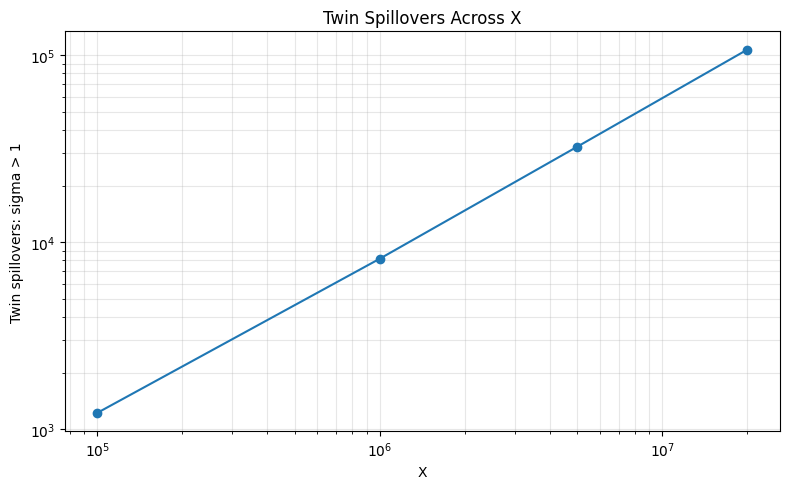

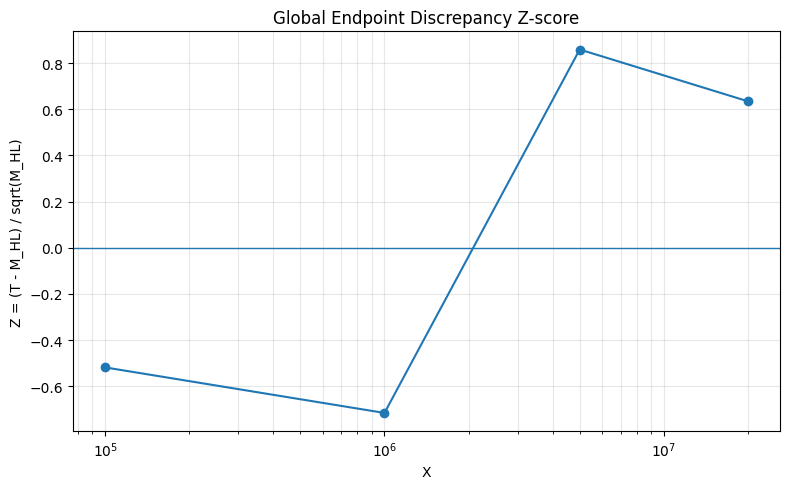

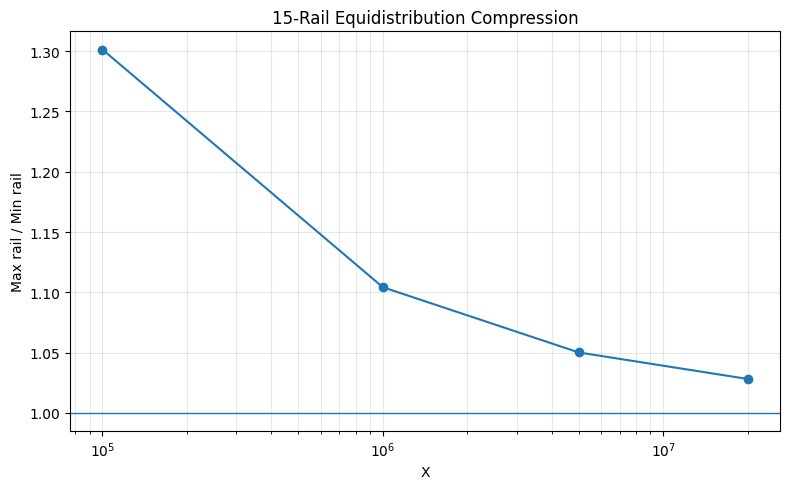

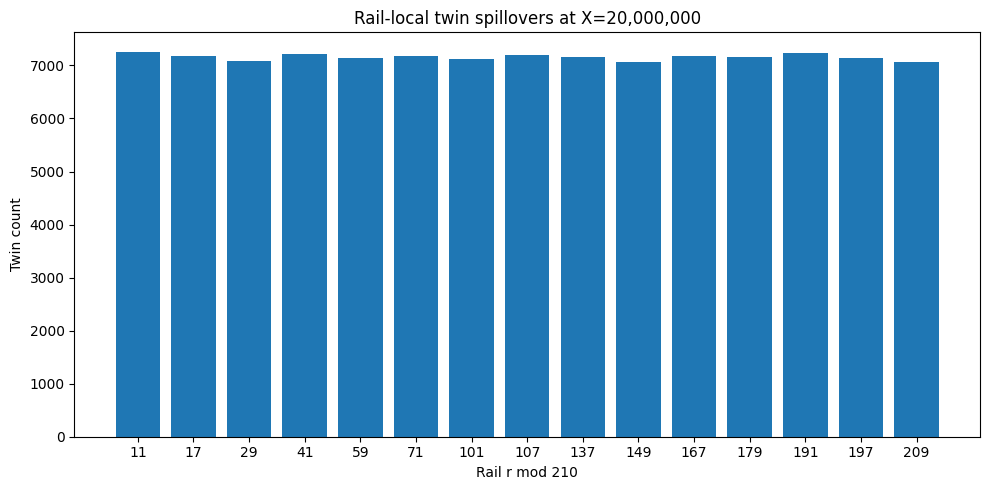

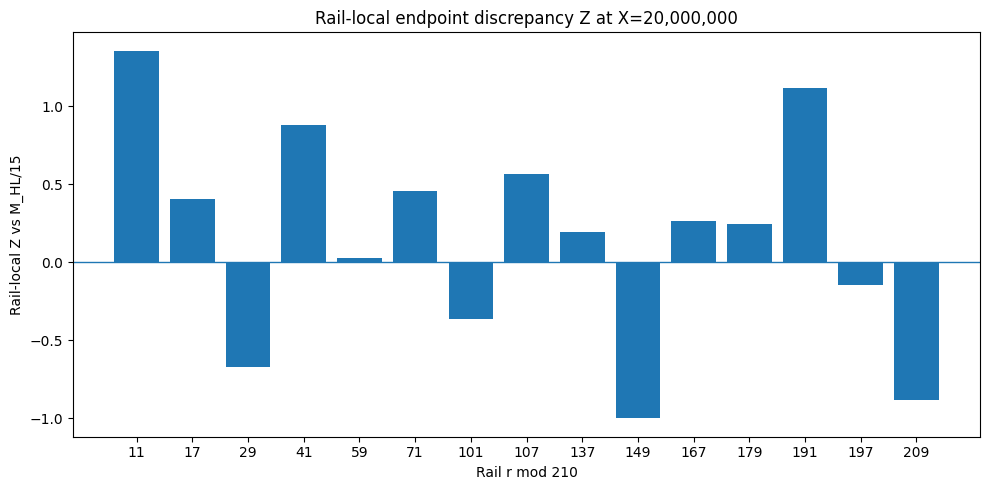

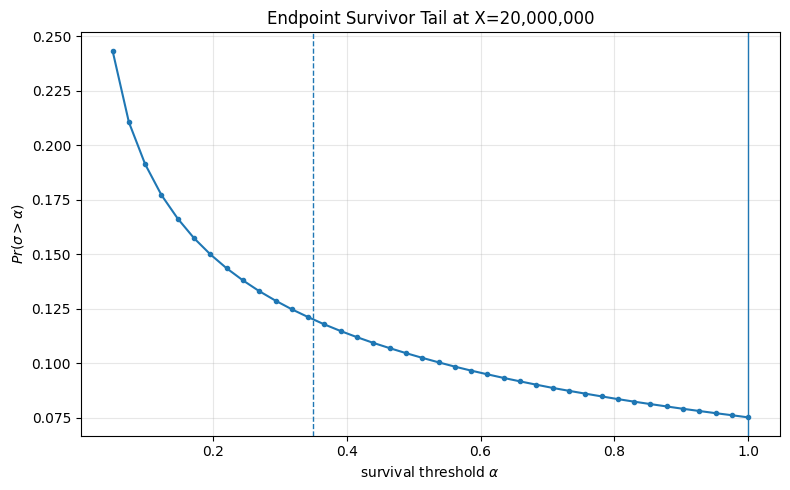

(    alpha  tail_count  tail_probability
 0  0.0500      347559          0.243291
 1  0.0744      300709          0.210496
 2  0.0987      273220          0.191254
 3  0.1231      252983          0.177088
 4  0.1474      237578          0.166305,
      alpha  tail_count  tail_probability
 35  0.9026      113026          0.079118
 36  0.9269      111589          0.078112
 37  0.9513      110169          0.077118
 38  0.9756      108823          0.076176
 39  1.0000      107405          0.075183)

In [3]:
save_outputs(summary, raw, CONFIG["OUTPUT_DIR"])
plot_summary(summary, CONFIG["OUTPUT_DIR"])
plot_last_rail_counts(raw, CONFIG["OUTPUT_DIR"])
tail_df = plot_tail_curve(max(CONFIG["X_GRID"]), CONFIG)
tail_df.head(), tail_df.tail()